# Windrose Tilt Summaries

Direction and magnitude summaries for AE/CE tilt vectors.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
mag_bins = [0, 10, 20, 30, 40, np.inf]
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121


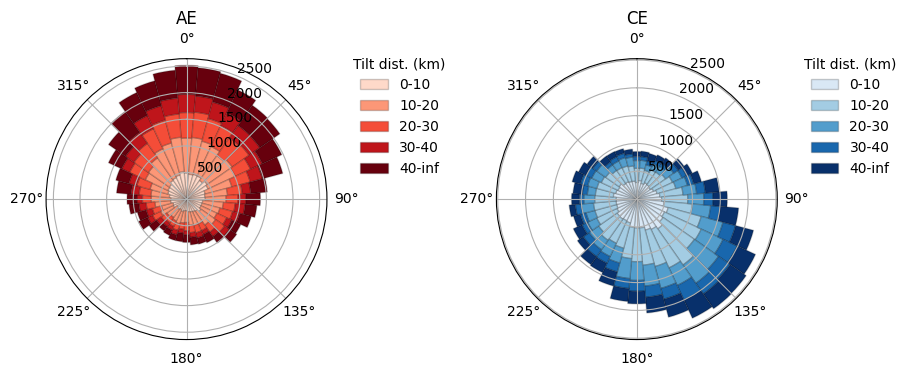

In [2]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    tilt.plot_windrose(ax, subset, title=cyc, mag_bins=mag_bins, colors=colors)
    ax.legend(title="Tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
plt.show()


## Regional rose plot

This uses the shared `rose_plot` helper so the same regional windrose layout can be reused in other notebooks.


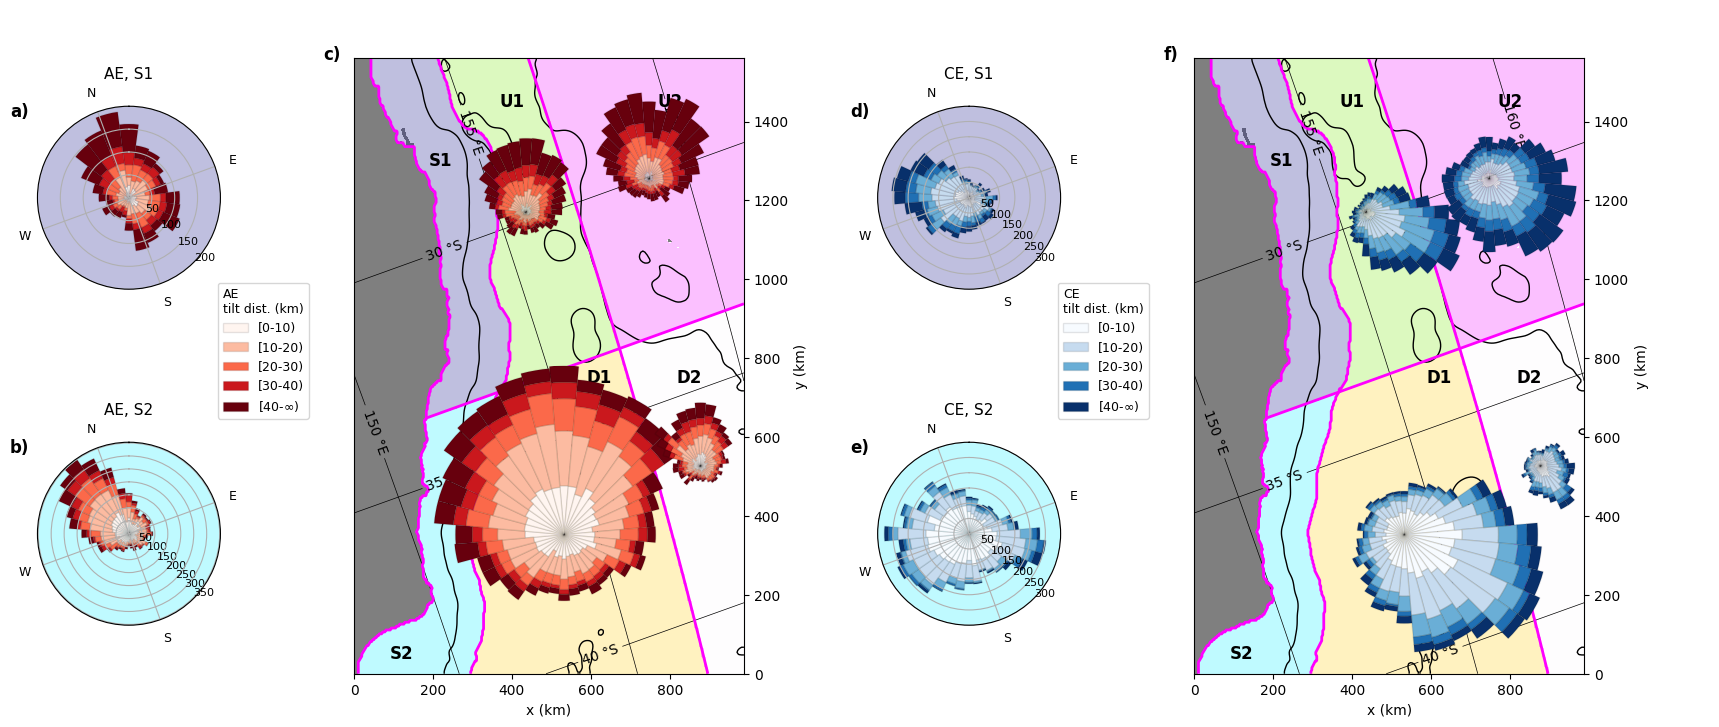

In [5]:
fig, rose = tilt.rose_plot(
    df_eddies,
    grid,
    mag="TiltDis",
    theta="TiltDir",
    mag_bins=mag_bins,
    frac=2.6,
    direction_offset=-20,
    shelf_offset=80,
    legend_title="tilt dist. (km)",
)
